# Aula 03 — Preenchendo as lacunas de nuvem com Sentinel-2

super-resolvido

A Aula 02 gerou buracos na cena CBERS-4A. Agora vamos preenche-los com
Sentinel-2. A grande questão é a escala: o WPM tem **2 m** e o MSI tem
**10 m**. Se colocassemos um pedaço de Sentinel-2 direto no CBERS
produziria uma mancha visivelmente borrada.

**AVISO:** Nessa etapa iremos substituir as áreas com imagens de outro
satélite, tendo em vista que a revisita do satélite CBERS-4A é de 30
dias. Se no seu estudo a distância de imagens não for uma questão que
apresente significativas alternâncias no uso e cobertura da terra, vale
a pena tentar substituir com imagens do mesmo sensor. Nesse caso,
estamos substituindo com o Sentinel-2 devido à necessidade de
visualizarmos o uso e cobertura da terra no período escolhido e a
ausência de imagens do CBERS.

O caminho que vamos fazer tem quatro etapas, e cada uma resolve um
problema diferente:

| etapa | problema que resolve | ferramenta |
|------------------------|------------------------|------------------------|
| 1\. mosaico Sentinel-2 | achar dado limpo perto da data do CBERS | STAC do Planetary Computer |
| 2\. super-resolução | refina a resolução de 10 m para 2 m | SEN2SR (10 m → 2,5 m) |
| 3\. coregistro | as duas imagens não estão exatamente alinhadas | AROSICS |
| 4\. harmonização e emenda | sensores diferentes têm brilho e resposta diferentes | casamento de histograma |

> **2,5 m não é 2 m.** A saída do SEN2SR é 2,5 m e a nossa grade é 2 m,
> e nós vamos reamostrar. O erro introduzido é pequeno, mas existe, e
> isso precisa ser declarado quando você escrever sobre o método.

**Nós usaremos a versão Lite do SEN2SR.** A versão completa usa
arquitetura Mamba e depende do pacote `mamba-ssm`, que exige GPU NVIDIA
com CUDA 12+ e kernels compilados — exigindo processamento em Linux. A
Lite roda em qualquer máquina, inclusive sem placa de vídeo. Trata-se de
uma boa escolha em quesito custo-benefício de processamento e qualidade.

> **Tudo nesta aula acontece na mesma bounding box e, do passo 3 em
> diante, na mesma grade de 2 m do CBERS.** Ao gerarmos os dois mosaicos
> (Sentinel-2 + CBERS-4A com buracos) com a mesma área possibilita a
> ferramenta AROSICS ter o que casar. Se você mudou o bbox em alguma
> aula, ajuste esse código antes de continuar.

## Preparando o ambiente (Colab)

**No pixi local não faz nada.** No Colab, a primeira célula instala o
conda e **reinicia a sessão** — aqui ela não é opcional: o AROSICS
depende do GDAL do conda-forge e não instala de forma confiável só com
`pip`.

> Esta aula é a mais pesada do curso. No Colab, ative a GPU antes de
> começar: **Ambiente de execução → Alterar o tipo de ambiente de
> execução → T4 GPU**. Sem GPU ela roda, só demora bem mais.

In [3]:
# --- Colab, parte 1 de 2: instala o conda na sessão (REINICIA o ambiente) ---
import sys

NO_COLAB = "google.colab" in sys.modules
print("Ambiente:", "Google Colab" if NO_COLAB else "local (pixi/Jupyter)")

if NO_COLAB:
    !pip install -q condacolab
    import condacolab
    condacolab.install()   # o ambiente reinicia aqui — é esperado

Ambiente: local (pixi/Jupyter)

In [2]:
# --- Colab, parte 2 de 2: rode DEPOIS do reinício (leva alguns minutos) ---
import sys

NO_COLAB = "google.colab" in sys.modules
if NO_COLAB:
    !mamba install -q -y -c conda-forge rasterio pyproj arosics scikit-image pystac-client planetary-computer py6s sixs requests
    !pip install -q omnicloudmask sen2sr mlstac
    print("pronto")

## 0. Configuração

In [4]:
# --- Módulo de apoio e configuração ---
from pathlib import Path

REPO = "https://github.com/danfioramonte/geoprocessamento-cbers4a"

if not Path("aulas_cbers.py").exists():
    !git clone -q --depth 1 {REPO} /tmp/geo_repo
    !cp /tmp/geo_repo/colab/aulas_cbers.py .
    !cp -r /tmp/geo_repo/colab/config .

import aulas_cbers as ac
ac.configurar_gdal()

import json
import math
import tempfile
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import Affine
from rasterio.warp import reproject, transform_bounds
from rasterio.windows import Window, from_bounds
from scipy.ndimage import binary_dilation, distance_transform_edt

In [5]:
CENA_ID = ac.CENA_PADRAO
NIVEL = "boa"                 # o mesmo das aulas 01 e 02

# --- mosaico Sentinel-2 ---
JANELA_DIAS = 45              # busca S2 nesta janela em torno da data do CBERS
NUVEM_MAX = 80                # descarta de cara cenas S2 mais nubladas que isso (%)
MARGEM_M = 240                # folga além da AOI, em metros (24 px de 10 m)
MAX_CENAS = 8                 # candidatas lidas (as mais próximas em data)

# Máscara de nuvem do Sentinel-2. Só o que o SCL chama de nuvem de verdade:
#   8 nuvem prob. média | 9 nuvem prob. alta | 10 cirros
# Se a cena que você escolheu TIVER nuvem, acrescente 3 (sombra de nuvem) —
# mas saiba que o SCL chama água escura de sombra o tempo todo, e isso abre
# buraco em represa e rio.
MASCARA_SCL = True            # False = usa a cena inteira, sem máscara nenhuma
CLASSES_NUVEM = (8, 9, 10)
DILATA_NUVEM_PX = 0           # buffer em torno da nuvem, em px de 10 m

# --- SEN2SR ---
MODELO = "lite"               # "lite" (CPU ou GPU) ou "full" (exige mamba-ssm)
TILE, FATOR, OVERLAP = 128, 4, 32     # bloco de entrada, ampliação, sobreposição

# --- coregistro ---
GRID_RES, JANELA_COREG = 200, 256     # espaçamento dos pontos e janela de correlação
MAX_SHIFT, MIN_RELIAB = 8, 60
CPUS = 2 if NO_COLAB else 4

# --- substituição ---
METODO_HARM = "momentos"      # momentos | linear | histograma | minmax
LARGURA_TRANSICAO = 25        # px de 2 m -> 50 m de transição suave
FAIXA = 2048                  # linhas processadas por vez na escrita do mosaico
ANEL_LACUNA = 0               # >0 ajusta a harmonização só num anel em torno dos buracos

# Faixa física da reflectância gravada — a mesma da Aula 01. A harmonização do
# S2 é uma reta (a*x + b) com b negativo em algumas bandas, então ela sozinha
# consegue produzir valor abaixo de zero mesmo partindo de um S2 já não-negativo.
# O piso fecha a conta no produto final.
PISO_REFLECTANCIA = ac.PISO_REFLECTANCIA      # 0.0
TETO_REFLECTANCIA = ac.TETO_REFLECTANCIA      # 1.6
PISO_ESC = PISO_REFLECTANCIA * ac.ESCALA
TETO_ESC = TETO_REFLECTANCIA * ac.ESCALA

NODATA = ac.NODATA            # -9999
NODATA_TMP = -9999.0
P = ac.pastas()
DATA = ac.data_da_cena(CENA_ID)
DATA_ISO = f"{DATA[:4]}-{DATA[4:6]}-{DATA[6:]}"

print(f"cena CBERS : {CENA_ID}  ({DATA_ISO})")
print(f"nível      : {NIVEL.upper()}")
print(f"S2         : {DATA_ISO} ± {JANELA_DIAS} dias")

cena CBERS : CBERS_4A_WPM_20260301_203_141_L4  (2026-03-01)
nível      : BOA
S2         : 2026-03-01 ± 45 dias

In [6]:
# Entradas vindas das aulas anteriores. Se faltarem, o atalho refaz tudo:
# aquisição (00) -> reflectância e fusão (01) -> máscara de nuvem (02).
fus = P["interim"] / f"pansharpening_{DATA}_{NIVEL}.tif"
cbers_mascarado = P["interim"] / f"{fus.stem}_masked.tif"
cloudmask = P["interim"] / f"{fus.stem}_cloudmask_native.tif"

if not (cbers_mascarado.exists() and cloudmask.exists()):
    r = ac.preparar_aula_03(CENA_ID, NIVEL)
    NIVEL = r["nivel"]
    fus = P["interim"] / f"pansharpening_{DATA}_{NIVEL}.tif"
    cbers_mascarado, cloudmask = Path(r["mascarada"]), Path(r["cloudmask"])

with rasterio.open(cbers_mascarado) as src:
    CRS_ALVO = src.crs
    BOUNDS_CBERS = src.bounds
    T_CBERS, H_CBERS, W_CBERS = src.transform, src.height, src.width
    RES_CBERS = src.res[0]
    NOMES = list(src.descriptions)

print(f"CBERS mascarado: {W_CBERS} x {H_CBERS} px @ {RES_CBERS:g} m | {CRS_ALVO}")
print(f"bandas         : {NOMES}")
print(f"máscara        : {cloudmask.name}")

CBERS mascarado: 5144 x 5256 px @ 2 m | EPSG:32723
bandas         : ['red', 'green', 'blue', 'nir']
máscara        : pansharpening_20260301_boa_cloudmask_native.tif

### Visualizando nossa área de estudo (CBERS-4A com buracos)

Make this Notebook Trusted to load map: File -> Trust Notebook <iframe srcdoc="<!DOCTYPE html>
<html>
<head>
 
 <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
 <script src="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.js"></script>
 <script src="https://code.jquery.com/jquery-3.7.1.min.js"></script>
 <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/js/bootstrap.bundle.min.js"></script>
 <script src="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.js"></script>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/css/bootstrap.min.css"/>
 <link rel="stylesheet" href="https://netdna.bootstrapcdn.com/bootstrap/3.0.0/css/bootstrap-glyphicons.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/@fortawesome/fontawesome-free@6.2.0/css/all.min.css"/>
 <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/gh/python-visualization/folium/folium/templates/leaflet.awesome.rotate.min.css"/>
 
 <meta name="viewport" content="width=device-width,
 initial-scale=1.0, maximum-scale=1.0, user-scalable=no" />
 <style>
 #map_7adba415627037e929f34195ffaee7cf {
 position: relative;
 width: 100.0%;
 height: 100.0%;
 left: 0.0%;
 top: 0.0%;
 }
 .leaflet-container { font-size: 1rem; }
 </style>

 <style>html, body {
 width: 100%;
 height: 100%;
 margin: 0;
 padding: 0;
 }
 </style>

 <style>#map {
 position:absolute;
 top:0;
 bottom:0;
 right:0;
 left:0;
 }
 </style>

 <script>
 L_NO_TOUCH = false;
 L_DISABLE_3D = false;
 </script>

 
 
 
 <style>
 .leaflet-image-layer {
 /* old android/safari*/
 image-rendering: -webkit-optimize-contrast;
 image-rendering: crisp-edges; /* safari */
 image-rendering: pixelated; /* chrome */
 image-rendering: -moz-crisp-edges; /* firefox */
 image-rendering: -o-crisp-edges; /* opera */
 -ms-interpolation-mode: nearest-neighbor; /* ie */
 }
 </style>
 
 
</head>
<body>
 
 
 <div class="folium-map" id="map_7adba415627037e929f34195ffaee7cf" ></div>
 
</body>
<script>
 
 
 var map_7adba415627037e929f34195ffaee7cf = L.map(
 "map_7adba415627037e929f34195ffaee7cf",
 {
 center: [-22.42086155245635, -47.54590682799616],
 crs: L.CRS.EPSG3857,
 ...{
 "zoom": 12,
 "zoomControl": true,
 "preferCanvas": false,
}

 }
 );

 

 
 
 var tile_layer_50284ecfc960ae4c933c978796d240ee = L.tileLayer(
 "https://tile.openstreetmap.org/{z}/{x}/{y}.png",
 {
 "minZoom": 0,
 "maxZoom": 19,
 "maxNativeZoom": 19,
 "noWrap": false,
 "attribution": "\u0026copy; \u003ca href=\"https://www.openstreetmap.org/copyright\"\u003eOpenStreetMap\u003c/a\u003e contributors",
 "subdomains": "abc",
 "detectRetina": false,
 "tms": false,
 "opacity": 1,
}

 );
 
 
 tile_layer_50284ecfc960ae4c933c978796d240ee.addTo(map_7adba415627037e929f34195ffaee7cf);
 
 
 var image_overlay_24989ac502de147ba46eb3212e60e72b = L.imageOverlay(
 "",
 [[-22.46908498996447, -47.596706251619466], [-22.372638114948234, -47.49510740437285]],
 {
 "opacity": 1.0,
 "crossOrigin": false,
}
 );
 
 
 image_overlay_24989ac502de147ba46eb3212e60e72b.addTo(map_7adba415627037e929f34195ffaee7cf);
 
 
 var layer_control_178d282ab06a34c2caafdb4ec71dc074_layers = {
 base_layers : {
 "openstreetmap" : tile_layer_50284ecfc960ae4c933c978796d240ee,
 },
 overlays : {
 "CBERS-4A com lacunas" : image_overlay_24989ac502de147ba46eb3212e60e72b,
 },
 };
 let layer_control_178d282ab06a34c2caafdb4ec71dc074 = L.control.layers(
 layer_control_178d282ab06a34c2caafdb4ec71dc074_layers.base_layers,
 layer_control_178d282ab06a34c2caafdb4ec71dc074_layers.overlays,
 {
 "position": "topright",
 "collapsed": true,
 "autoZIndex": true,
}
 ).addTo(map_7adba415627037e929f34195ffaee7cf);

 
 
 map_7adba415627037e929f34195ffaee7cf.fitBounds(
 [[-22.46908498996447, -47.596706251619466], 
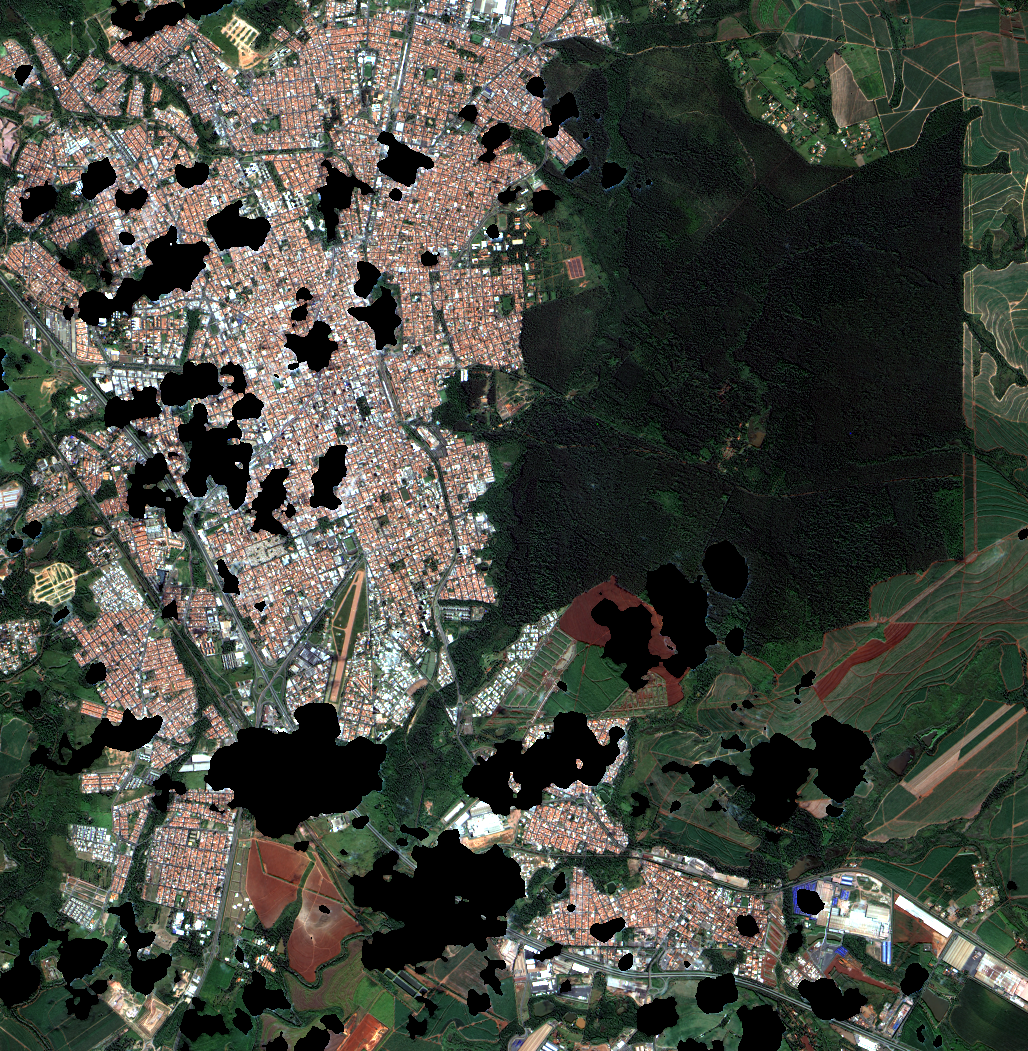

In [7]:
import folium

# Reduz a imagem para tornar o mapa mais leve
MAX_DIM = 1200
fator = max(1, int(np.ceil(max(H_CBERS, W_CBERS) / MAX_DIM)))
forma_folium = (H_CBERS // fator, W_CBERS // fator)

with rasterio.open(cbers_mascarado) as src:
    rgb = src.read(
        (1, 2, 3),
        out_shape=(3, *forma_folium),
        resampling=Resampling.average
    ).astype("float32")
    nodata_folium = src.nodata

if nodata_folium is not None:
    rgb[:, rgb[0] <= nodata_folium + 1] = np.nan

imagem_folium = np.dstack([
    (np.nan_to_num(ac.stretch(b), nan=0) * 255).astype("uint8")
    for b in rgb
])

# Limites da imagem em latitude/longitude
west, south, east, north = transform_bounds(
    CRS_ALVO, "EPSG:4326", *BOUNDS_CBERS
)

centro = [(south + north) / 2, (west + east) / 2]

mapa = folium.Map(
    location=centro,
    zoom_start=12,
    tiles="OpenStreetMap"
)

folium.raster_layers.ImageOverlay(
    image=imagem_folium,
    bounds=[[south, west], [north, east]],
    opacity=1.0,
    cross_origin=False,
    name="CBERS-4A com lacunas"
).add_to(mapa)

folium.LayerControl().add_to(mapa)
mapa.fit_bounds([[south, west], [north, east]])

mapa

## 1. Montando o mosaico Sentinel-2

O script original desta etapa fazia a montagem do mosaico via Google
Earth Engine. Aqui a gente monta o mosaico direto do **STAC do Microsoft
Planetary Computer**: é uma maneira mais dinâmica, onde você consegue
baixar as imagens sem conta, sem autenticação e sem esperar export.

**A grade é definida pelo CBERS:** mesmo CRS, mesma origem, resolução de
10 m, e uma margem de alguns pixels além da AOI. A margem existe porque
o coregistro desloca a imagem — sem folga, a borda ficaria sem dado
depois do deslocamento — o AROSICS precisa de contexto além do buraco
para achar pontos de amarração.

**Composição por data mais próxima.** Para cada pixel, pegamos a cena S2
**mais próxima em data** que esteja limpa ali, segundo a banda SCL do
produto L2A. Preserva a textura real de uma data, ao invés de misturar
datas num borrão. A principal questão é que pixels vizinhos podem vir de
datas diferentes — por isso gravamos a banda **`delta_days`**, que
registra de quantos dias de distância veio cada pixel.

> **O deslocamento da baseline 04.00.** Desde 25/01/2022 os produtos
> Sentinel-2 L2A trazem um offset de −1000 na reflectância: o valor
> físico é `(DN − 1000) / 10000`, e não `DN / 10000`. Esquecer isso
> desloca a reflectância inteira em 0,1 — o que sobrevive à harmonização
> empírica e depois aparece como um viés inexplicável. A célula abaixo
> lê a baseline de cada item e aplica o offset quando for o caso.

In [8]:
import pandas as pd
import planetary_computer as pc
from pystac_client import Client

# grade alvo: 10 m, encaixada na grade do CBERS, com margem
res_s2 = 10.0
minx = math.floor((BOUNDS_CBERS.left - MARGEM_M) / res_s2) * res_s2
miny = math.floor((BOUNDS_CBERS.bottom - MARGEM_M) / res_s2) * res_s2
maxx = math.ceil((BOUNDS_CBERS.right + MARGEM_M) / res_s2) * res_s2
maxy = math.ceil((BOUNDS_CBERS.top + MARGEM_M) / res_s2) * res_s2
W_S2, H_S2 = int((maxx - minx) / res_s2), int((maxy - miny) / res_s2)
T_S2 = Affine(res_s2, 0, minx, 0, -res_s2, maxy)
BOUNDS_ALVO = (minx, miny, maxx, maxy)

bbox_4326 = transform_bounds(CRS_ALVO, "EPSG:4326", *BOUNDS_ALVO)
data_ref = datetime.fromisoformat(DATA_ISO).replace(tzinfo=timezone.utc)
ini = (data_ref - timedelta(days=JANELA_DIAS)).date().isoformat()
fim = (data_ref + timedelta(days=JANELA_DIAS)).date().isoformat()

catalogo = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1",
                       modifier=pc.sign_inplace)
itens = list(catalogo.search(collections=["sentinel-2-l2a"], bbox=list(bbox_4326),
                             datetime=f"{ini}/{fim}",
                             query={"eo:cloud_cover": {"lt": NUVEM_MAX}}).items())

def delta_dias(item):
    d = datetime.fromisoformat(str(item.properties["datetime"]).replace("Z", "+00:00"))
    return (d - data_ref).days

itens.sort(key=lambda it: abs(delta_dias(it)))
print(f"grade do mosaico: {W_S2} x {H_S2} px @ {res_s2:g} m ({CRS_ALVO})")
print(f"{len(itens)} cenas Sentinel-2 entre {ini} e {fim}")
print("nuvem_cena_% é da CENA INTEIRA (~110 km), não da sua AOI — a prévia da "
      "próxima seção mede na AOI.\n")

df_s2 = pd.DataFrame([{
    "idx": i,
    "data": str(it.properties["datetime"])[:10],
    "delta_dias": delta_dias(it),
    "nuvem_cena_%": round(float(it.properties.get("eo:cloud_cover", float("nan"))), 1),
    "tile": it.properties.get("s2:mgrs_tile", "?"),
    "baseline": str(it.properties.get("s2:processing_baseline", "?")),
    "id": it.id,
} for i, it in enumerate(itens)])
df_s2.head(20)

grade do mosaico: 1078 x 1100 px @ 10 m (EPSG:32723)
27 cenas Sentinel-2 entre 2026-01-15 e 2026-04-15
nuvem_cena_% é da CENA INTEIRA (~110 km), não da sua AOI — a prévia da próxima seção mede na AOI.


In [9]:
# Funções de leitura usadas daqui até o fim da seção 1.
ASSETS = {"red": "B04", "green": "B03", "blue": "B02", "nir": "B08"}
LIMIAR_BASELINE = datetime(2022, 1, 25, tzinfo=timezone.utc)


def offset_da_baseline(item):
    """Desde a baseline 04.00 a reflectância do L2A vem com offset de -1000."""
    baseline = str(item.properties.get("s2:processing_baseline", ""))
    quando = datetime.fromisoformat(str(item.properties["datetime"]).replace("Z", "+00:00"))
    try:
        return (-1000.0 if float(baseline) >= 4.0 else 0.0), baseline
    except ValueError:
        return (-1000.0 if quando >= LIMIAR_BASELINE else 0.0), baseline


def ler_para_grade(href, dtype="float32", resampling=Resampling.bilinear,
                   forma=None, transform=None):
    """Lê um asset e o reprojeta para a grade alvo (CRS e transform do CBERS).

    Com `forma` e `transform` lê para uma grade mais grossa — é assim que as
    prévias saem baratas, aproveitando as visões reduzidas do COG.
    """
    forma = forma or (H_S2, W_S2)
    transform = T_S2 if transform is None else transform
    saida = np.zeros(forma, dtype=dtype)
    with rasterio.open(href) as src:
        b = transform_bounds(CRS_ALVO, src.crs, *BOUNDS_ALVO, densify_pts=21)
        jan = from_bounds(*b, src.transform).round_offsets().round_lengths()
        c0, r0 = int(jan.col_off) - 4, int(jan.row_off) - 4
        c1 = int(jan.col_off + jan.width) + 4
        r1 = int(jan.row_off + jan.height) + 4
        c0, r0 = max(0, c0), max(0, r0)
        c1, r1 = min(src.width, c1), min(src.height, r1)
        if c1 <= c0 or r1 <= r0:
            return None                       # a cena não cobre a AOI
        jan = Window(c0, r0, c1 - c0, r1 - r0)
        arr = src.read(1, window=jan)
        reproject(source=arr, destination=saida,
                  src_transform=src.window_transform(jan), src_crs=src.crs,
                  dst_transform=transform, dst_crs=CRS_ALVO, resampling=resampling)
    return saida

### 1.2 Vendo as candidatas antes de escolher

A coluna `nuvem_cena_%` da tabela a cima refere-se a **cena inteira**. A
nossa AOI tem 10 km: uma cena com 40% de nuvem pode estar limpa na AOI,
ao mesmo tempo que uma com 3% pode ter justamente nuvem na área que
estamos analisando.

A célula abaixo lê uma versão recortada de cada cena **só na AOI**. Para
cada uma você vê a cor natural na sua área e a fração limpa **medida
ali**.

Estamos fazendo a mesma coisa que fizemos na cena da Aula 00: o número
nos dá parâmetros, mas precisamos visualizar a imagem para chegar em uma
conclusão.

In [10]:
MAX_PREVIA = 8
NUVEM_MAX_PREVIA = 60.0

# Mantém os índices originais e exclui cenas com mais de 60% de nuvem
itens_previa = [
    (i, item) for i, item in enumerate(itens)
    if float(item.properties.get("eo:cloud_cover", 0)) <= NUVEM_MAX_PREVIA
][:MAX_PREVIA]

fator_p = max(1, int(np.ceil(max(H_S2, W_S2) / 280)))
forma_p = (max(1, H_S2 // fator_p), max(1, W_S2 // fator_p))
T_p = T_S2 * Affine.scale(fator_p, fator_p)

previas = []
for i, item in itens_previa:
    if any(a not in item.assets for a in ("B04", "B03", "B02", "SCL")):
        continue

    scl = ler_para_grade(item.assets["SCL"].href, "uint8",
                         Resampling.nearest, forma_p, T_p)
    if scl is None:
        continue

    off, _ = offset_da_baseline(item)
    rgb = [
        np.clip(
            ler_para_grade(item.assets[a].href, "float32",
                           Resampling.average, forma_p, T_p) + off,
            0, 32000
        )
        for a in ("B04", "B03", "B02")
    ]

    dentro = rgb[0] > 0
    limpo = ~np.isin(scl, CLASSES_NUVEM) & dentro

    previas.append({
        "idx": i,
        "item": item,
        "rgb": rgb,
        "cobre_aoi": float(dentro.mean()),
        "limpo_aoi": float(limpo.mean())
    })

    print(f"[{i}] {str(item.properties['datetime'])[:10]}  "
          f"Δ{delta_dias(item):>+4} d | cobre {dentro.mean():6.1%} da AOI | "
          f"limpo (SCL) {limpo.mean():6.1%} | "
          f"{item.properties.get('s2:mgrs_tile', '?')}")

colunas = 4
linhas = max(1, int(np.ceil(len(previas) / colunas)))
fig, axes = plt.subplots(linhas, colunas,
                         figsize=(4 * colunas, 4.5 * linhas),
                         squeeze=False)

for ax, pv in zip(axes.ravel(), previas):
    ax.imshow(np.dstack([
        ac.stretch(np.where(pv["rgb"][0] > 0, b, np.nan))
        for b in pv["rgb"]
    ]))
    ax.set_title(
        f"[{pv['idx']}] {str(pv['item'].properties['datetime'])[:10]}  "
        f"Δ{delta_dias(pv['item']):+d} d\n"
        f"cobre {pv['cobre_aoi']:.0%} | limpo {pv['limpo_aoi']:.0%}",
        fontsize=10
    )

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

[1] 2026-03-04  Δ  +3 d | cobre 100.0% da AOI | limpo (SCL)  91.2% | 23KKR
[2] 2026-03-04  Δ  +3 d | cobre 100.0% da AOI | limpo (SCL)  95.0% | 22KHA
[5] 2026-02-22  Δ  -7 d | cobre 100.0% da AOI | limpo (SCL)  44.6% | 23KKR
[6] 2026-02-22  Δ  -7 d | cobre 100.0% da AOI | limpo (SCL)  44.9% | 22KHA
[7] 2026-02-17  Δ -12 d | cobre 100.0% da AOI | limpo (SCL)  87.4% | 23KKR
[8] 2026-02-17  Δ -12 d | cobre 100.0% da AOI | limpo (SCL)  87.3% | 22KHA
[9] 2026-03-14  Δ +13 d | cobre 100.0% da AOI | limpo (SCL) 100.0% | 23KKR
[10] 2026-03-14  Δ +13 d | cobre 100.0% da AOI | limpo (SCL) 100.0% | 22KHA

### 1.3 Escolhendo as cenas

Sobre a célula abaixo: `ESCOLHA_S2 = None` deixa no automático —
escolhendo todas as `MAX_CENAS` mais próximas em data. Nós podemos
escolher quais cenas vamos utilizar a partir da **lista de `idx`**,
estabelecendo uma **ordem de preferência de preenchimento**: a primeira
da lista preenche o que puder, a segunda preenche o que sobrou, e assim
por diante.

> **Uma AOI pode cair na emenda de dois tiles MGRS.** Quando isso
> acontece, a mesma data aparece duas vezes na tabela, com `tile`
> diferente, e **cada uma cobre um pedaço** da sua área — a coluna
> `cobre` da prévia mostra isso. Nesse caso coloque as duas na lista:

> ESCOLHA_S2 = [1, 2, 9, 10]

Utilizar o STAC nos permite gerar esses thumbnails que facilitam a
fotointerpretação e devemos usar a tecnologia a nosso favor. Na célula
abaixo, definimos as cenas candidatas (1 ,2, 9 e 10).

In [13]:
# None = automático (as MAX_CENAS mais próximas em data)
# lista de idx = você escolhe, na ordem de preferência. Ex.: [3, 4]
ESCOLHA_S2 = [1, 2, 9, 10]

if ESCOLHA_S2:
    selecionadas = [itens[i] for i in ESCOLHA_S2]
    print("seleção manual, nesta ordem de preferência:")
else:
    selecionadas = itens[:MAX_CENAS]
    print(f"seleção automática: as {len(selecionadas)} mais próximas em data")

for it in selecionadas:
    print(f"  Δ{delta_dias(it):>+4} d  {str(it.properties['datetime'])[:10]}  "
          f"{it.properties.get('s2:mgrs_tile', '?'):<7} {it.id}")

if not selecionadas:
    raise SystemExit("nenhuma cena selecionada — confira ESCOLHA_S2.")

seleção manual, nesta ordem de preferência:
  Δ  +3 d  2026-03-04  23KKR   S2B_MSIL2A_20260304T132229_R038_T23KKR_20260304T183249
  Δ  +3 d  2026-03-04  22KHA   S2B_MSIL2A_20260304T132229_R038_T22KHA_20260304T183249
  Δ +13 d  2026-03-14  23KKR   S2B_MSIL2A_20260314T132229_R038_T23KKR_20260314T182541
  Δ +13 d  2026-03-14  22KHA   S2B_MSIL2A_20260314T132229_R038_T22KHA_20260314T182541

### 1.4 A máscara de nuvem

O satélite Sentinel-2 conta com uma camada de qualidade que classifica
cada pixel das imagens, chamada de SCL. Dentro das classes de uso dos
pixels, temos as classes de nuvem. As classes de nuvem são: 8
(probabilidade média), 9 (probabilidade alta) e 10 (cirros).

Como podemos visualizar na cena 1 e 2, há uma leve névoa na parte
sudeste da imagem e iremos evitar a contaminação de pixels no mosaico
que irá substituir. O SCL identifica a névoa nessas imagens e remove os
pixels, abrindo espaço para que as cenas 9 e 10 (que elegemos
anteriormente) substituam os pixels contaminados, gerando um mosaico
livre de nuvens.

> **Se a sua cena tiver nuvem**, volte em **0. Configuração** e
> acrescente a classe **3 (sombra de nuvem)** em `CLASSES_NUVEM`. Fica o
> aviso: o SCL confunde **água escura com sombra de nuvem** com
> frequência, então isso costuma abrir gerar buracos em represas e rios.
> Confira o painel “candidatas limpas por pixel” depois.

Se você escolheu uma imagem 100% limpa e sem pixels contaminados, volte
em **0. Configuração** e defina `MASCARA_SCL = False`. Isso desliga a
filtragem SCL e usa a cena exatamente como veio.

Sobre a regra de escolha por pixel: entre as candidatas com dado limpo,
vence a **primeira da ordem** — a mais próxima em data no automático,
ou, nesse caso, a que colocamos primeiro em `ESCOLHA_S2` (Cena 1 \> Cena
2 \> Cena 9 \> Cena 10).

``` python
# ---- 1. lê as selecionadas e monta a máscara de cada uma -------------------
candidatas, usadas = [], []
print(f"{'cena':<44} {'delta':>6} {'cobre':>7} {'limpo':>7}")

for item in selecionadas:
    if any(a not in item.assets for a in list(ASSETS.values()) + ["SCL"]):
        continue
    bandas = [ler_para_grade(item.assets[a].href) for a in ASSETS.values()]
    if any(b is None for b in bandas):
        continue

    offset, baseline = offset_da_baseline(item)
    pilha = np.clip(np.stack(bandas) + offset, 0, 32000)
    dentro = (pilha > 0).any(axis=0)          # onde esta cena cobre a AOI

    limpo = dentro.copy()
    if MASCARA_SCL:
        scl = ler_para_grade(item.assets["SCL"].href, "uint8", Resampling.nearest)
        if scl is not None:
            nuvem = np.isin(scl, CLASSES_NUVEM)
            if DILATA_NUVEM_PX:
                nuvem = binary_dilation(nuvem, iterations=DILATA_NUVEM_PX)
            limpo &= ~nuvem

    if not limpo.any():
        print(f"{item.id[:44]:<44} {delta_dias(item):>+6} {dentro.mean():>6.1%} "
              f"{0.0:>6.1%}  descartada")
        continue

    candidatas.append({"item": item, "pilha": pilha, "limpo": limpo,
                       "delta": delta_dias(item), "baseline": baseline,
                       "offset": offset, "cobre": float(dentro.mean()),
                       "frac_limpa": float(limpo.mean())})
    print(f"{item.id[:44]:<44} {delta_dias(item):>+6} {dentro.mean():>6.1%} "
          f"{limpo.mean():>6.1%}")

if not candidatas:
    raise SystemExit("nenhuma cena Sentinel-2 utilizável. Reveja ESCOLHA_S2, "
                     "ou aumente JANELA_DIAS / NUVEM_MAX.")

# ---- 2. escolha por pixel: a primeira da ordem que tiver dado limpo --------
escolha = np.full((H_S2, W_S2), -1, dtype="int16")
for i, c in enumerate(candidatas):
    falta = (escolha < 0) & c["limpo"]
    escolha[falta] = i

# ---- 3. monta o mosaico -----------------------------------------------------
n_limpos = np.sum([c["limpo"] for c in candidatas], axis=0).astype("int16")
refl = np.zeros((4, H_S2, W_S2), dtype="float32")
delta = np.zeros((H_S2, W_S2), dtype="int16")
preenchido = escolha >= 0

for i, c in enumerate(candidatas):
    sel = escolha == i
    if not sel.any():
        continue
    refl[:, sel] = c["pilha"][:, sel]
    delta[sel] = c["delta"]
    usadas.append({"id": c["item"].id,
                   "data": str(c["item"].properties["datetime"])[:10],
                   "delta_dias": c["delta"], "baseline": c["baseline"],
                   "offset": c["offset"], "cobre_aoi": round(c["cobre"], 4),
                   "frac_limpa": round(c["frac_limpa"], 4),
                   "px_usados": int(sel.sum())})
    print(f"{c['item'].id[:44]:<44} -> {sel.sum():,} px usados")

for c in candidatas:
    c.pop("pilha", None)

print(f"\ncobertura final do mosaico: {preenchido.mean():.2%} "
      f"({len(usadas)} cenas contribuíram)")
if preenchido.mean() < 0.99:
    print("Sobrou buraco. Se a cena está visivelmente limpa ali, é falso positivo do")
    print("SCL: tire a classe 3 de CLASSES_NUVEM, ou use MASCARA_SCL = False.")
```

    cena                                          delta   cobre   limpo
    S2B_MSIL2A_20260304T132229_R038_T23KKR_20260     +3 100.0%  91.2%
    S2B_MSIL2A_20260304T132229_R038_T22KHA_20260     +3 100.0%  95.0%
    S2B_MSIL2A_20260314T132229_R038_T23KKR_20260    +13 100.0% 100.0%
    S2B_MSIL2A_20260314T132229_R038_T22KHA_20260    +13 100.0% 100.0%
    S2B_MSIL2A_20260304T132229_R038_T23KKR_20260 -> 1,081,050 px usados
    S2B_MSIL2A_20260304T132229_R038_T22KHA_20260 -> 45,777 px usados
    S2B_MSIL2A_20260314T132229_R038_T23KKR_20260 -> 58,973 px usados

    cobertura final do mosaico: 100.00% (3 cenas contribuíram)

Tabela 1

In [15]:
s2_10m = P["interim"] / f"S2_{DATA}_10m.tif"
perfil_s2 = dict(driver="GTiff", dtype="int16", count=6, height=H_S2, width=W_S2,
                 transform=T_S2, crs=CRS_ALVO, nodata=NODATA, compress="deflate",
                 predictor=2, tiled=True, blockxsize=512, blockysize=512,
                 BIGTIFF="IF_SAFER", interleave="band")

with rasterio.open(s2_10m, "w", **perfil_s2) as dst:
    for i in range(4):
        b = np.where(preenchido, np.rint(refl[i]), NODATA)
        dst.write(b.astype("int16"), i + 1)
    dst.write(np.where(preenchido, delta, -32768).astype("int16"), 5)
    dst.write(preenchido.astype("int16"), 6)
    for i, nome in enumerate(["red", "green", "blue", "nir", "delta_days", "valid"], 1):
        dst.set_band_description(i, nome)
    dst.update_tags(ORDEM_BANDAS="RGBN", FATOR_ESCALA="10000",
                    CENAS=json.dumps([u["id"] for u in usadas]))

s2_10m.with_suffix(".params.json").write_text(json.dumps(
    {"gerado_em": datetime.now().isoformat(timespec="seconds"), "aula": "03",
     "etapa": "mosaico S2", "data_referencia": DATA_ISO,
     "janela_dias": JANELA_DIAS, "nuvem_max": NUVEM_MAX, "margem_m": MARGEM_M,
          "mascara_scl": MASCARA_SCL, "classes_nuvem": list(CLASSES_NUVEM),
     "dilata_nuvem_px": DILATA_NUVEM_PX, "cenas": usadas,
     "cobertura": float(preenchido.mean())},
    indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Escrito: {s2_10m.name}  ({s2_10m.stat().st_size / 1024**2:.1f} MB)")

Escrito: S2_20260301_10m.tif  (6.6 MB)

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(19, 6.5))
rgb = np.dstack([ac.stretch(np.where(preenchido, refl[i], np.nan)) for i in range(3)])
ax[0].imshow(rgb)
ax[0].set_title("Mosaico Sentinel-2 10 m — composição por data mais próxima")

im = ax[1].imshow(np.where(preenchido, delta, np.nan), cmap="coolwarm",
                  vmin=-JANELA_DIAS, vmax=JANELA_DIAS)
ax[1].set_title("delta_days — distância em dias até a data do CBERS")
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04, label="dias")

# quantas candidatas tinham dado limpo em cada pixel. Onde é 0, o mosaico ficou
# com buraco: ou nenhuma cena cobre ali, ou o SCL marcou nuvem em todas.
im2 = ax[2].imshow(n_limpos, cmap="viridis", vmin=0, vmax=max(1, int(n_limpos.max())))
ax[2].set_title("candidatas com dado limpo, por pixel")
fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04, label="nº de cenas")

for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()

if (n_limpos == 0).any():
    print(f"{int((n_limpos == 0).sum()):,} px sem nenhuma candidata limpa "
          f"({(n_limpos == 0).mean():.2%} da grade) — são os brancos do mosaico.")
    print("Compare com a prévia: se a imagem está limpa ali, é o SCL errando. "
          "Ajuste CLASSES_NUVEM ou ponha MASCARA_SCL = False.")

## 2. Super-resolução com o SEN2SR

O SEN2SR leva o Sentinel-2 de 10 m para 2,5 m. Ele não inventa
informação que não existe: o modelo aprendeu como cenas de alta
resolução costumam se parecer e usa isso para reconstruir detalhe
**plausível**. Isso é suficiente para a emenda não gritar, e é honesto
declarar que a textura da área preenchida é reconstruída, não observada.

Três detalhes de implementação que não são cosméticos:

- **o janelamento é nosso, não do `predict_large`.** A função pronta
  entrega blocos de borda truncados ao modelo, e o módulo
  `hard_constraint` do SEN2SR quebra, porque a máscara FFT dele é fixa.
  Aqui todo bloco tem exatamente 128×128;
- **preenchimento por vizinho mais próximo antes da inferência.** O
  campo receptivo da rede propagaria zeros para dentro dos pixels bons
  se deixássemos buraco. O conteúdo desses pixels é descartado no fim;
- **acolchoamento por reflexão e mistura com rampa.** As bordas dos
  blocos recebem peso crescente, então a costura entre blocos vizinhos
  some. A rampa começa em 0,001 e não em zero porque na borda externa da
  cena não há bloco vizinho somando peso.

In [17]:
import mlstac
import torch

URLS = {"lite": ("https://huggingface.co/tacofoundation/sen2sr/resolve/main/"
                 "SEN2SRLite/NonReference_RGBN_x4/mlm.json"),
        "full": ("https://huggingface.co/tacofoundation/sen2sr/resolve/main/"
                 "SEN2SR/NonReference_RGBN_x4/mlm.json")}
DIR_MODELO = Path("model") / ("SEN2SRLite_RGBN" if MODELO == "lite" else "SEN2SR_RGBN")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("dispositivo:", device)

if not DIR_MODELO.exists():
    DIR_MODELO.parent.mkdir(parents=True, exist_ok=True)
    print(f"baixando os pesos ({MODELO})...")
    mlstac.download(file=URLS[MODELO], output_dir=str(DIR_MODELO))

try:
    modelo = mlstac.load(str(DIR_MODELO)).compiled_model(device=device)
except ImportError as e:
    if "mamba" in str(e).lower() or "causal_conv1d" in str(e).lower():
        raise SystemExit("O modelo 'full' exige mamba-ssm com kernels CUDA compilados. "
                         "Use MODELO = 'lite'.")
    raise
print("modelo carregado")

dispositivo: cpu
modelo carregado

In [18]:
stride = TILE - OVERLAP
tile_hr = TILE * FATOR
margem_hr = OVERLAP * FATOR // 2

arr = refl / 10000.0                       # o modelo espera reflectância 0-1
valid = preenchido.copy()

if not valid.all():
    _, idx = distance_transform_edt(~valid, return_distances=True, return_indices=True)
    arr = arr[:, idx[0], idx[1]]           # vizinho mais próximo nos buracos
arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")

def dim_pad(n):
    return TILE if n <= TILE else TILE + math.ceil((n - TILE) / stride) * stride

Hp, Wp = dim_pad(H_S2), dim_pad(W_S2)
arr_p = np.pad(arr, ((0, 0), (0, Hp - H_S2), (0, Wp - W_S2)), mode="reflect")
valid_p = np.pad(valid, ((0, Hp - H_S2), (0, Wp - W_S2)), mode="constant",
                 constant_values=False)
ys = list(range(0, Hp - TILE + 1, stride))
xs = list(range(0, Wp - TILE + 1, stride))
print(f"entrada {W_S2} x {H_S2} -> acolchoado {Wp} x {Hp} -> "
      f"{len(ys) * len(xs)} blocos de {TILE}x{TILE}")

tmp = Path(tempfile.mkdtemp(prefix="sen2sr_"))
Hh, Wh = Hp * FATOR, Wp * FATOR
acc = np.lib.format.open_memmap(tmp / "acc.npy", mode="w+", dtype="float32",
                                shape=(4, Hh, Wh))
wsum = np.lib.format.open_memmap(tmp / "w.npy", mode="w+", dtype="float32",
                                 shape=(Hh, Wh))

rampa = np.linspace(1e-3, 1.0, margem_hr, dtype="float32")
perfil_peso = np.ones(tile_hr, dtype="float32")
perfil_peso[:margem_hr] = rampa
perfil_peso[-margem_hr:] = rampa[::-1]
peso = perfil_peso[:, None] * perfil_peso[None, :]

feitos = pulados = 0
with torch.no_grad():
    for y0 in ys:
        for x0 in xs:
            if not valid_p[y0:y0 + TILE, x0:x0 + TILE].any():
                pulados += 1
                continue
            bloco = np.ascontiguousarray(arr_p[:, y0:y0 + TILE, x0:x0 + TILE])
            X = torch.from_numpy(bloco[None]).float().to(device)
            pred = modelo(X).detach().cpu().numpy()[0]
            Y0, X0 = y0 * FATOR, x0 * FATOR
            acc[:, Y0:Y0 + tile_hr, X0:X0 + tile_hr] += pred * peso
            wsum[Y0:Y0 + tile_hr, X0:X0 + tile_hr] += peso
            feitos += 1
    print(f"blocos processados: {feitos} | pulados (vazios): {pulados}")

del modelo
if device.type == "cuda":
    torch.cuda.empty_cache()

entrada 1078 x 1100 -> acolchoado 1088 x 1184 -> 132 blocos de 128x128
blocos processados: 132 | pulados (vazios): 0

In [19]:
Hs, Ws = H_S2 * FATOR, W_S2 * FATOR
valid_sr = np.repeat(np.repeat(valid, FATOR, axis=0), FATOR, axis=1)

s2_sr = P["interim"] / f"S2_{DATA}_SR2p5m.tif"
perfil_sr = dict(driver="GTiff", dtype="float32", count=4, height=Hs, width=Ws,
                 transform=T_S2 * Affine.scale(1 / FATOR), crs=CRS_ALVO,
                 nodata=np.nan, compress="deflate", predictor=3, tiled=False,
                 BIGTIFF="IF_SAFER", interleave="band")

with rasterio.open(s2_sr, "w", **perfil_sr) as dst:
    for r0 in range(0, Hs, 2048):
        r1 = min(r0 + 2048, Hs)
        bloco = (acc[:, r0:r1, :Ws] / np.maximum(wsum[r0:r1, :Ws], 1e-6)).astype("float32")
        bloco[:, ~valid_sr[r0:r1, :Ws]] = np.nan
        dst.write(bloco, window=Window(0, r0, Ws, r1 - r0))
    for i, nome in enumerate(["red", "green", "blue", "nir"], 1):
        dst.set_band_description(i, nome)      # rótulos: as etapas seguintes leem daqui
    dst.update_tags(MODELO=f"SEN2SR-{MODELO}", RESOLUCAO_M=str(10 / FATOR))

del acc, wsum
for f in tmp.glob("*.npy"):
    f.unlink()
tmp.rmdir()
print(f"Escrito: {s2_sr.name}  ({Ws} x {Hs} px @ {10 / FATOR} m, "
      f"{s2_sr.stat().st_size / 1024**2:.1f} MB)")

Escrito: S2_20260301_SR2p5m.tif  (4312 x 4400 px @ 2.5 m, 202.2 MB)

In [20]:
# 10 m x 2,5 m no mesmo pedaço de terreno
lado = min(120, H_S2 // 3, W_S2 // 3)
r0, c0 = H_S2 // 2 - lado // 2, W_S2 // 2 - lado // 2
antes = refl[:3, r0:r0 + lado, c0:c0 + lado] / 10000.0
with rasterio.open(s2_sr) as src:
    depois = src.read((1, 2, 3), window=Window(c0 * FATOR, r0 * FATOR,
                                               lado * FATOR, lado * FATOR))

fig, ax = plt.subplots(1, 2, figsize=(13, 6.6))
ax[0].imshow(np.dstack([ac.stretch(b) for b in antes]))
ax[0].set_title("Sentinel-2 original — 10 m")
ax[1].imshow(np.dstack([ac.stretch(b) for b in depois]))
ax[1].set_title(f"SEN2SR {MODELO} — 2,5 m")
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()

## 3. Reamostragem para 2 m e coregistro com o AROSICS

Duas imagens de satélites diferentes nunca caem exatamente uma sobre a
outra: ortorretificação, modelo de elevação e efeito de paralaxe do
relevo produzem deslocamentos de um a alguns pixels. Em 2 m isso é
visível — e numa emenda, é o que faz uma estrada aparecer cortada.

O **AROSICS** resolve por correlação de fase: ele acha pontos de
amarração numa malha regular, mede o deslocamento local em cada um,
filtra os não confiáveis e deforma a imagem alvo.

Dois cuidados importantes:

- **a correlação de fase é insensível a diferença radiométrica linear**,
  então não importa que as duas imagens tenham brilho diferente. A
  harmonização vem *depois* do coregistro, não antes;
- **o AROSICS só acha ponto onde as DUAS imagens têm dado válido.** Por
  isso passamos máscaras de “dado ruim”: no CBERS, os buracos de nuvem e
  o nodata; no S2, o que ficou fora do mosaico. Tentar correlacionar
  dentro do buraco seria correlacionar ruído.

A **banda de validade viaja junto** com a imagem no coregistro, como uma
banda extra, para sofrer exatamente a mesma deformação. Na volta, o
limiar de 0,99 devolve o caráter binário — erodindo cerca de um pixel na
borda, o que é conservador de propósito.

In [21]:
with rasterio.open(cbers_mascarado) as src:
    cbers = src.read().astype("float32")
    cbers_nodata = src.nodata
cbers[cbers <= -9000] = np.nan
nodata_cbers = ~np.isfinite(cbers).all(axis=0)

with rasterio.open(cloudmask) as src:
    if (src.height, src.width) != (H_CBERS, W_CBERS):
        raise ValueError("a máscara de nuvem não está na grade do CBERS. "
                         "Refaça a Aula 02 sobre este mesmo pansharpening.")
    classes = src.read(1)
lacuna = np.isin(classes, [1, 2, 3])

print(f"nodata no CBERS: {nodata_cbers.mean():.2%}")
print(f"lacuna de nuvem: {lacuna.mean():.2%}")
print(f"concordância entre a máscara e o buraco da imagem: "
      f"{(lacuna & nodata_cbers).sum() / max((lacuna | nodata_cbers).sum(), 1):.1%} (Jaccard)")

nodata no CBERS: 12.75%
lacuna de nuvem: 12.74%
concordância entre a máscara e o buraco da imagem: 100.0% (Jaccard)

In [22]:
# S2-SR de 2,5 m -> 2 m, na grade exata do CBERS
with rasterio.open(s2_sr) as src:
    sr = src.read().astype("float32")
    t_sr, crs_sr = src.transform, src.crs
    nomes_sr = [d or n for d, n in zip(src.descriptions, ac.NOMES_SAIDA)]
print("ordem das bandas do S2-SR:", nomes_sr)

sr_valid = np.isfinite(sr).all(axis=0)
if not sr_valid.all():
    _, idx = distance_transform_edt(~sr_valid, return_distances=True, return_indices=True)
    sr = sr[:, idx[0], idx[1]]

pilha = np.concatenate([sr, sr_valid.astype("float32")[None]], axis=0)
pilha_2m = np.empty((pilha.shape[0], H_CBERS, W_CBERS), dtype="float32")
for i in range(pilha.shape[0]):
    reproject(source=pilha[i], destination=pilha_2m[i],
              src_transform=t_sr, src_crs=crs_sr,
              dst_transform=T_CBERS, dst_crs=CRS_ALVO,
              resampling=Resampling.cubic, num_threads=CPUS)
del sr, pilha
print(f"S2-SR reamostrado para {RES_CBERS:g} m na grade do CBERS: "
      f"{W_CBERS} x {H_CBERS} px")

ordem das bandas do S2-SR: ['red', 'green', 'blue', 'nir']
S2-SR reamostrado para 2 m na grade do CBERS: 5144 x 5256 px

In [23]:
trab = P["interim"] / f"coreg_tmp_{DATA}"
trab.mkdir(parents=True, exist_ok=True)

perfil_tmp = dict(driver="GTiff", dtype="float32", count=cbers.shape[0],
                  height=H_CBERS, width=W_CBERS, transform=T_CBERS, crs=CRS_ALVO,
                  nodata=NODATA_TMP, compress="deflate", predictor=3, tiled=False)

ref_tmp = trab / "cbers_ref.tif"
with rasterio.open(ref_tmp, "w", **perfil_tmp) as dst:
    dst.write(np.nan_to_num(cbers, nan=NODATA_TMP))

tgt_tmp = trab / "s2sr_2m_pre_coreg.tif"
with rasterio.open(tgt_tmp, "w", **dict(perfil_tmp, count=pilha_2m.shape[0])) as dst:
    dst.write(pilha_2m)

# convenção do AROSICS: True = excluir da correlação
bad_ref = lacuna | nodata_cbers
bad_tgt = pilha_2m[-1] < 0.99
sobreposicao = float((~bad_ref & ~bad_tgt).mean())
print(f"área útil para correlação: {sobreposicao:.2%} da cena")
if sobreposicao < 0.10:
    raise SystemExit("sobreposição válida insuficiente para coregistrar.")

perfil_mask = dict(driver="GTiff", dtype="uint8", count=1, height=H_CBERS,
                   width=W_CBERS, transform=T_CBERS, crs=CRS_ALVO,
                   compress="deflate", tiled=False)
mask_ref_p, mask_tgt_p = trab / "bad_ref.tif", trab / "bad_tgt.tif"
for caminho, m in [(mask_ref_p, bad_ref), (mask_tgt_p, bad_tgt)]:
    with rasterio.open(caminho, "w", **perfil_mask) as dst:
        dst.write(m.astype("uint8"), 1)
print("máscaras de dado ruim gravadas")

área útil para correlação: 87.25% da cena
máscaras de dado ruim gravadas

``` python
BANDA_MATCH = 4          # NIR: é a banda com mais textura e menos efeito atmosférico
sr_coreg = trab / "s2sr_2m_coreg.tif"
info_coreg = {}

try:
    from arosics import COREG_LOCAL

    CR = COREG_LOCAL(str(ref_tmp), str(tgt_tmp),
                     grid_res=GRID_RES, window_size=(JANELA_COREG, JANELA_COREG),
                     min_reliability=MIN_RELIAB, tieP_filter_level=3,
                     r_b4match=BANDA_MATCH, s_b4match=BANDA_MATCH,
                     max_shift=MAX_SHIFT, nodata=(NODATA_TMP, NODATA_TMP),
                     mask_baddata_ref=str(mask_ref_p), mask_baddata_tgt=str(mask_tgt_p),
                     path_out=str(sr_coreg), fmt_out="GTiff",
                     projectDir=str(trab), CPUs=CPUS, q=False)
    CR.correct_shifts()

    tbl = CR.CoRegPoints_table
    ok = tbl[(tbl["ABS_SHIFT"] != -9999) & (~tbl["OUTLIER"].astype(bool))]
    desloc = np.hypot(ok["X_SHIFT_M"].values, ok["Y_SHIFT_M"].values)
    info_coreg = {"metodo": "arosics local", "pontos_confiaveis": int(len(ok)),
                  "pontos_totais": int(len(tbl)),
                  "desloc_mediano_m": float(np.median(desloc)),
                  "desloc_p90_m": float(np.percentile(desloc, 90))}
    print(f"\npontos confiáveis   : {len(ok)} de {len(tbl)}")
    print(f"deslocamento mediano: {info_coreg['desloc_mediano_m']:.3f} m "
          f"({info_coreg['desloc_mediano_m'] / RES_CBERS:.3f} px)")
    print(f"deslocamento p90    : {info_coreg['desloc_p90_m']:.3f} m")
    if len(ok) < 20:
        print("AVISO: poucos pontos confiáveis. A cena pode ter pouca textura, ou a "
              "lacuna pode estar grande demais.")
    try:
        tbl.to_file(trab / "tiepoints.gpkg", driver="GPKG")
    except Exception:
        pass

except Exception as erro:
    # Plano B: deslocamento GLOBAL por correlação de fase. Não corrige
    # deformação local, mas resolve o caso comum de um deslocamento constante —
    # e é melhor que seguir sem coregistro nenhum.
    print(f"AROSICS indisponível ou falhou ({type(erro).__name__}: {erro}).")
    print("Usando o plano B: deslocamento global por correlação de fase.")
    from scipy.ndimage import shift as nd_shift
    from skimage.registration import phase_cross_correlation

    m = ~bad_ref & ~bad_tgt
    a = np.where(m, np.nan_to_num(cbers[BANDA_MATCH - 1]), 0.0)
    b = np.where(m, pilha_2m[BANDA_MATCH - 1], 0.0)
    desl, _, _ = phase_cross_correlation(a, b, upsample_factor=10)
    print(f"deslocamento estimado (linhas, colunas): {desl}")
    corr = np.stack([nd_shift(pilha_2m[i], desl, order=1, mode="nearest")
                     for i in range(pilha_2m.shape[0])])
    with rasterio.open(sr_coreg, "w",
                       **dict(perfil_tmp, count=corr.shape[0])) as dst:
        dst.write(corr)
    info_coreg = {"metodo": "correlacao de fase (global)",
                  "desloc_linhas_px": float(desl[0]), "desloc_colunas_px": float(desl[1]),
                  "desloc_mediano_m": float(np.hypot(*desl) * RES_CBERS)}
```

    Calculating footprint polygon and actual data corner coordinates for reference image...

    Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00
    C:\geo\geoprocessamento-cbers4a\.pixi\envs\default\Lib\site-packages\arosics\CoReg.py:122: UserWarning: The footprint of the reference image contains multiple separate image parts. AROSICS will only process the largest image part.
      warnings.warn(f'The footprint of the {self.imName} contains multiple separate image parts. '

    Bounding box of calculated footprint for reference image:
        (232788.0, 7513110.0, 243076.0, 7523622.0)
    Calculating footprint polygon and actual data corner coordinates for image to be shifted...
    Bounding box of calculated footprint for image to be shifted:
        (232788.0, 7513110.0, 243076.0, 7523622.0)
    Matching window position (X,Y): 237963.4417975617/7518391.642822992
    Initializing tie points grid...
    With respect to the provided bad data mask(s) 79 points of initially 690 have been excluded.
    Calculating tie point grid (611 points) using 4 CPU cores...

        progress: |==================================================| 100.0% Complete  => 0:02:20

    Found 409 matches.
    Performing validity checks...
    148 tie points flagged by level 1 filtering (reliability).
    124 tie points flagged by level 2 filtering (SSIM).
    6 tie points flagged by level 3 filtering (RANSAC)
    191 valid tie points remain after filtering.
    Correcting geometric shifts...

    Translating progress |==================================================| 100.0% Complete  => 0:00:00
    Warping progress     |==================================================| 100.0% Complete  => 0:00:01

    Writing GeoArray of size (5256, 5144, 5) to C:\geo\geoprocessamento-cbers4a\colab\data\interim\coreg_tmp_20260301\s2sr_2m_coreg.tif.

    pontos confiáveis   : 191 de 611
    deslocamento mediano: 12.721 m (6.361 px)
    deslocamento p90    : 15.419 m

Tabela 2

In [25]:
with rasterio.open(sr_coreg) as src:
    corr = src.read().astype("float32")

valid_final = corr[-1] >= 0.99
s2_2m = corr[:4].copy()
s2_2m[:, ~valid_final] = np.nan
del corr, pilha_2m          # libera memória: são centenas de MB cada

saida_s2 = P["interim"] / f"S2_{DATA}_2m_coreg.tif"
with rasterio.open(saida_s2, "w", **dict(perfil_tmp, count=4, nodata=np.nan)) as dst:
    dst.write(s2_2m)
    for i, nome in enumerate(nomes_sr, 1):
        dst.set_band_description(i, nome)
print(f"Escrito: {saida_s2.name} | cobertura válida: {valid_final.mean():.2%}")

# procedência: de quando veio cada pixel. Vizinho mais próximo e SEM correção de
# deslocamento — esta banda documenta a data, não posiciona nada.
delta_2m = np.empty((H_CBERS, W_CBERS), dtype="int16")
reproject(source=delta, destination=delta_2m, src_transform=T_S2, src_crs=CRS_ALVO,
          dst_transform=T_CBERS, dst_crs=CRS_ALVO, resampling=Resampling.nearest)
delta_2m[~valid_final] = -32768

saida_delta = P["interim"] / f"S2_{DATA}_2m_delta_days.tif"
with rasterio.open(saida_delta, "w", **dict(perfil_tmp, count=1, dtype="int16",
                                            nodata=-32768, predictor=2)) as dst:
    dst.write(delta_2m, 1)
    dst.set_band_description(1, "delta_days")
print(f"Escrito: {saida_delta.name}")

Escrito: S2_20260301_2m_coreg.tif | cobertura válida: 99.88%
Escrito: S2_20260301_2m_delta_days.tif

## 4. Harmonização e substituição

Faltam duas decisões, e as duas mudam o resultado visível.

**Em que escala fica o produto final?** O Sentinel-2 é convertido para a
escala do CBERS, e não o contrário. Assim o mosaico continua comparável
com as outras cenas CBERS da sua série temporal, sem precisar
reprocessar nenhuma delas.

**Como casar a radiometria?** Um par de coeficientes por banda, ajustado
sobre os pixels em que as duas imagens são válidas ao mesmo tempo. O
padrão é **casamento de momentos** — média e desvio-padrão:

- `momentos` preserva a variância do S2, então a **textura** da área
  preenchida combina com a do entorno. É o que costuma resolver
  diferença de brilho e de assinatura espectral;
- `linear` (regressão por mínimos quadrados) dá coeficientes bonitos de
  reportar, mas **encolhe a variância**: a área preenchida sai mais lisa
  que a vizinhança, e isso aparece;
- `histograma` casa a distribuição inteira por quantis, acomodando
  relação não linear entre os sensores, mas não produz coeficiente
  reportável;
- `minmax` casa os extremos; sensível a outlier, por isso usa percentis
  0,5 e 99,5.

Com `ANEL_LACUNA > 0`, o ajuste é calculado só numa faixa em torno dos
buracos. Serve para quando a área que estava sob nuvem é
sistematicamente diferente do resto da cena — mais úmida, mais vegetada
— e a relação entre os sensores ali não é a média da cena.

**A transição.** Como a lacuna é um buraco no CBERS, não há com o que
misturar *dentro* dela. A transição acontece do lado de fora, invadindo
alguns pixels de CBERS válido ao redor. Ou seja: uma faixa estreita de
dado nativo é parcialmente substituída — é o preço de uma emenda sem
degrau, e a banda de procedência registra exatamente onde isso
aconteceu.

> **O piso de reflectância**
>
> A harmonização é uma reta $a\,x + b$, e o $b$ sai negativo em algumas
> bandas. Isso significa que ela consegue produzir valor abaixo de zero
> **mesmo partindo de um Sentinel-2 que já não tinha nenhum negativo**.
> Somado à cauda escura que vem da fusão da Aula 01, é o que fazia o
> mosaico final aparecer no QGIS com mínimo negativo.
>
> O mosaico é gravado com o mesmo piso da Aula 01 (`PISO_REFLECTANCIA`,
> seção 0), e o notebook reporta quantos pixels de cada banda foram
> ceifados. Como o nodata é `-9999`, o pixel ceifado vale 0 e **continua
> valendo como dado**.

In [26]:
rng = np.random.default_rng(42)
T_AMOSTRA, N_AMOSTRAS = 512, 120
pares = {n: ([], []) for n in nomes_sr}
coletadas, tentativas = 0, 0

# As duas imagens estão em RGBN, mas em vez de confiar nisso a gente casa banda a
# banda PELO NOME gravado no arquivo. Uma troca silenciosa de R por B não quebra
# nada — só faz a harmonização ajustar o vermelho do S2 contra o azul do CBERS.
nomes_cbers = [(d or "").strip().lower() for d in NOMES]
if all(n in nomes_cbers for n in nomes_sr):
    ordem_cb = [nomes_cbers.index(n) for n in nomes_sr]
else:
    print(f"AVISO: rótulos do CBERS ({nomes_cbers}) não reconhecidos; "
          f"assumindo a mesma ordem do S2-SR.")
    ordem_cb = list(range(4))
print("pareamento banda a banda (S2 -> CBERS):",
      {n: ordem_cb[i] + 1 for i, n in enumerate(nomes_sr)})

cb_full = cbers[ordem_cb]            # (4, H, W) com NaN onde não há dado
s2_full = s2_2m

while coletadas < N_AMOSTRAS and tentativas < N_AMOSTRAS * 30:
    tentativas += 1
    r0 = int(rng.integers(0, max(1, H_CBERS - T_AMOSTRA)))
    c0 = int(rng.integers(0, max(1, W_CBERS - T_AMOSTRA)))
    cb = cb_full[:, r0:r0 + T_AMOSTRA, c0:c0 + T_AMOSTRA].astype("float64")
    s2 = s2_full[:, r0:r0 + T_AMOSTRA, c0:c0 + T_AMOSTRA].astype("float64")

    ok = np.isfinite(cb).all(axis=0) & np.isfinite(s2).all(axis=0)
    if ANEL_LACUNA > 0:
        buraco = ~np.isfinite(cb).all(axis=0) & np.isfinite(s2).all(axis=0)
        if not buraco.any():
            continue
        ok = ok & (distance_transform_edt(~buraco) <= ANEL_LACUNA)
        if ok.sum() < 2000:
            continue
    elif ok.mean() < 0.5:
        continue

    idx = np.flatnonzero(ok.ravel())
    if idx.size > 4000:
        idx = rng.choice(idx, 4000, replace=False)
    for i, n in enumerate(nomes_sr):
        pares[n][0].append(s2[i].ravel()[idx])
        pares[n][1].append(cb[i].ravel()[idx])
    coletadas += 1

if coletadas == 0:
    raise SystemExit("nenhuma janela com sobreposição válida suficiente para harmonizar.")
print(f"janelas amostradas: {coletadas}  "
      f"(escopo: {'anel das lacunas' if ANEL_LACUNA else 'cena inteira'})")

pareamento banda a banda (S2 -> CBERS): {'red': 1, 'green': 2, 'blue': 3, 'nir': 4}
janelas amostradas: 120  (escopo: cena inteira)

``` python
ajuste = {}
print(f"HARMONIZAÇÃO — Sentinel-2 para a escala do CBERS, método '{METODO_HARM}'\n")
print(f"{'banda':<7} {'a':>12} {'b':>12} {'média S2':>12} {'média CBERS':>13} {'n':>10}")

for n in nomes_sr:
    x = np.concatenate(pares[n][0])
    y = np.concatenate(pares[n][1])
    lo_x, hi_x = np.percentile(x, [1, 99])
    lo_y, hi_y = np.percentile(y, [1, 99])
    m = (x >= lo_x) & (x <= hi_x) & (y >= lo_y) & (y <= hi_y)
    x, y = x[m], y[m]

    if METODO_HARM == "momentos":
        a = float(y.std() / x.std()) if x.std() > 1e-12 else 1.0
        b = float(y.mean() - a * x.mean())
        ajuste[n] = dict(tipo="linear", a=a, b=b)
    elif METODO_HARM == "linear":
        coef = np.polyfit(x, y, 1)
        a, b = float(coef[0]), float(coef[1])
        pred = np.polyval(coef, x)
        r2 = 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        ajuste[n] = dict(tipo="linear", a=a, b=b, r2=float(r2))
    elif METODO_HARM == "minmax":
        x0, x1 = np.percentile(x, [0.5, 99.5])
        y0, y1 = np.percentile(y, [0.5, 99.5])
        a = float((y1 - y0) / (x1 - x0)) if (x1 - x0) > 1e-12 else 1.0
        b = float(y0 - a * x0)
        ajuste[n] = dict(tipo="linear", a=a, b=b)
    else:
        qs = np.linspace(0.5, 99.5, 199)
        ajuste[n] = dict(tipo="histograma", xq=np.percentile(x, qs).tolist(),
                         yq=np.percentile(y, qs).tolist())
        a = b = float("nan")
    ajuste[n]["n"] = int(x.size)
    print(f"{n:<7} {a:>12.2f} {b:>12.2f} {x.mean():>12.4f} {y.mean():>13.1f} {x.size:>10,}")

print("\nO coeficiente 'a' perto de 10.000 é esperado: o S2-SR está em reflectância 0-1 e o")
print("CBERS em reflectância x10.000. O que importa é o desvio em torno disso.")


def aplicar_harmonizacao(arr, n):
    p = ajuste[n]
    if p["tipo"] == "linear":
        return p["a"] * arr + p["b"]
    return np.interp(arr, p["xq"], p["yq"])
```

    HARMONIZAÇÃO — Sentinel-2 para a escala do CBERS, método 'momentos'

    banda              a            b     média S2   média CBERS          n
    red          8327.78       211.22       0.0764         847.6    463,560
    green        8229.74       191.34       0.0682         752.3    463,817
    blue         8178.09       143.41       0.0472         529.1    463,673
    nir          9222.86       249.81       0.2438        2498.4    464,186

    O coeficiente 'a' perto de 10.000 é esperado: o S2-SR está em reflectância 0-1 e o
    CBERS em reflectância x10.000. O que importa é o desvio em torno disso.

Tabela 3

In [28]:
COD = {"nodata": 0, "cbers": 1, "cbers_outra_data": 2, "s2sr": 3, "transicao": 5}
M = LARGURA_TRANSICAO

mosaico = P["processed"] / f"mosaico_{DATA}_gapfilled.tif"
procedencia = P["processed"] / f"mosaico_{DATA}_proveniencia.tif"

perfil_out = dict(driver="GTiff", dtype="int16", count=4, height=H_CBERS, width=W_CBERS,
                  transform=T_CBERS, crs=CRS_ALVO, nodata=NODATA, compress="deflate",
                  predictor=2, tiled=True, blockxsize=512, blockysize=512,
                  BIGTIFF="IF_SAFER", interleave="band")
perfil_prov = dict(perfil_out, count=1, dtype="uint8", nodata=0, predictor=2)

stats = dict(cbers=0, s2=0, transicao=0, vazio=0)
ceifados = {n: 0 for n in nomes_sr}      # quanto o piso de reflectância pegou
borda_dif = {n: [] for n in nomes_sr}
borda_sd = {n: [] for n in nomes_sr}

s2_harm = np.stack([aplicar_harmonizacao(s2_full[i], n)
                    for i, n in enumerate(nomes_sr)]).astype("float32")

with rasterio.open(mosaico, "w", **perfil_out) as dst, \
        rasterio.open(procedencia, "w", **perfil_prov) as dstp:
    for r0 in range(0, H_CBERS, FAIXA):
        r1 = min(r0 + FAIXA, H_CBERS)
        lr0, lr1 = max(0, r0 - M), min(H_CBERS, r1 + M)   # margem para a distância

        cb = cb_full[:, lr0:lr1]
        sh = s2_harm[:, lr0:lr1]
        cb_ok = np.isfinite(cb).all(axis=0)
        s2_ok = np.isfinite(sh).all(axis=0)
        buraco = ~cb_ok & s2_ok
        sem_nada = ~cb_ok & ~s2_ok

        if buraco.any():
            dist = distance_transform_edt(~buraco)
            w = np.clip(1.0 - dist / max(M, 1), 0.0, 1.0).astype("float32")
            anel = (dist <= 3) & cb_ok & s2_ok
        else:
            w = np.zeros(cb_ok.shape, dtype="float32")
            anel = np.zeros(cb_ok.shape, dtype=bool)
        w[~s2_ok] = 0.0
        w[buraco] = 1.0

        if anel.sum() > 500:      # descontinuidade medida na emenda
            for i, n in enumerate(nomes_sr):
                borda_dif[n].append(float(np.nanmean(sh[i][anel] - cb[i][anel])))
                sd_c = float(np.nanstd(cb[i][anel]))
                if sd_c > 1e-9:
                    borda_sd[n].append(float(np.nanstd(sh[i][anel])) / sd_c)

        saida = np.nan_to_num(cb, nan=0.0) * (1 - w) + np.nan_to_num(sh, nan=0.0) * w

        prov = np.full(cb_ok.shape, COD["nodata"], dtype="uint8")
        prov[cb_ok] = COD["cbers"]
        prov[(w > 0) & (w < 1)] = COD["transicao"]
        prov[buraco] = COD["s2sr"]
        prov[sem_nada] = COD["nodata"]

        corte = slice(r0 - lr0, r0 - lr0 + (r1 - r0))
        for k, cod in [("cbers", 1), ("s2", 3), ("transicao", 5), ("vazio", 0)]:
            stats[k] += int((prov[corte] == cod).sum())

        # Piso físico: reflectância negativa não existe. Vem de duas fontes — a
        # cauda escura da fusão (Aula 01) e o coeficiente linear negativo da
        # harmonização acima. Contamos antes de ceifar, para o número ir no
        # .params.json em vez de sumir.
        bruto = saida[:, corte]
        dado = prov[corte] != COD["nodata"]
        for k, n in enumerate(nomes_sr):
            ceifados[n] += int((bruto[k][dado] < PISO_ESC).sum())
        bloco = np.clip(np.rint(bruto), PISO_ESC, TETO_ESC).astype("int16")
        bloco[:, ~dado] = NODATA
        jan = Window(0, r0, W_CBERS, r1 - r0)
        dst.write(bloco, window=jan)
        dstp.write(prov[corte], 1, window=jan)

    for i, n in enumerate(nomes_sr, 1):
        dst.set_band_description(i, n)
    dst.update_tags(ORDEM_BANDAS="RGBN", FATOR_ESCALA="10000", NIVEL=NIVEL.upper(),
                    FAIXA_REFLECTANCIA=f"[{PISO_REFLECTANCIA}, {TETO_REFLECTANCIA}]")
    dstp.set_band_description(1, "proveniencia")
    dstp.update_tags(CODIGOS="0=sem dado,1=CBERS,2=CBERS outra data,"
                             "3=Sentinel-2 SR,5=transicao")

total = sum(stats.values())
print("COMPOSIÇÃO DO MOSAICO")
for rot, k in [("CBERS nativo", "cbers"), ("Sentinel-2 SR", "s2"),
               ("zona de transição", "transicao"), ("sem dado", "vazio")]:
    print(f"  {rot:<20} {stats[k]:>14,} px  ({stats[k] / total * 100:>6.2f}%)")

com_dado = total - stats["vazio"]
print(f"\nPISO DE REFLECTÂNCIA em {PISO_REFLECTANCIA:g} — pixels ceifados por banda:")
for n in nomes_sr:
    print(f"  {n:<8} {ceifados[n]:>14,} px  ({ceifados[n] / max(com_dado, 1) * 100:>6.3f}%)")
print("  (o pixel ceifado vale 0 e continua VÁLIDO; o nodata é -9999)")

COMPOSIÇÃO DO MOSAICO
  CBERS nativo             21,442,981 px  ( 79.31%)
  Sentinel-2 SR             3,443,454 px  ( 12.74%)
  zona de transição         2,146,971 px  (  7.94%)
  sem dado                      3,458 px  (  0.01%)

PISO DE REFLECTÂNCIA em 0 — pixels ceifados por banda:
  red                   0 px  ( 0.000%)
  green                 0 px  ( 0.000%)
  blue                  0 px  ( 0.000%)
  nir                   0 px  ( 0.000%)
  (o pixel ceifado vale 0 e continua VÁLIDO; o nodata é -9999)

### A emenda ficou boa?

Duas medidas, num anel de 3 px em volta de cada lacuna — onde as duas
imagens existem e podem ser comparadas diretamente:

- **viés**: a diferença média entre o S2 harmonizado e o CBERS. Perto de
  zero significa que não há degrau de brilho na emenda;
- **razão de desvios**: o desvio-padrão do S2 harmonizado dividido pelo
  do CBERS. Perto de 1 significa que a área preenchida tem variabilidade
  parecida com a do entorno. Bem abaixo de 1 quer dizer preenchimento
  mais liso — esperado com `linear`, sinal de problema com `momentos`.

Viés grande e do mesmo sinal em todas as bandas indica que o ajuste
global não descreve bem a área das lacunas: tente `ANEL_LACUNA = 200`.

``` python
print(f"{'banda':<8} {'viés':>14} {'razão de desvios':>20}")
for n in nomes_sr:
    v, r = borda_dif[n], borda_sd[n]
    vs = f"{np.mean(v):>+14.2f}" if v else f"{'-':>14}"
    rs = f"{np.mean(r):>20.3f}" if r else f"{'-':>20}"
    print(f"{n:<8} {vs} {rs}")

registro = {
    "gerado_em": datetime.now().isoformat(timespec="seconds"), "aula": "03",
    "cena_cbers": CENA_ID, "nivel": NIVEL, "data": DATA_ISO,
    "s2": {"janela_dias": JANELA_DIAS, "cenas": usadas,
           "cobertura_mosaico": float(preenchido.mean())},
    "sen2sr": {"modelo": MODELO, "tile": TILE, "overlap": OVERLAP,
               "fator": FATOR, "resolucao_saida_m": 10 / FATOR},
    "coregistro": info_coreg,
    "harmonizacao": {"metodo": METODO_HARM, "anel_lacuna_px": ANEL_LACUNA,
                     "por_banda": ajuste},
    "substituicao": {"largura_transicao_px": LARGURA_TRANSICAO,
                     "largura_transicao_m": LARGURA_TRANSICAO * RES_CBERS,
                     "composicao": stats},
    "faixa_reflectancia": [PISO_REFLECTANCIA, TETO_REFLECTANCIA],
    "px_ceifados_no_piso": ceifados,
    "vies_borda": {n: (float(np.mean(v)) if v else None) for n, v in borda_dif.items()},
    "razao_desvios_borda": {n: (float(np.mean(v)) if v else None)
                            for n, v in borda_sd.items()},
    "saidas": {"mosaico": str(mosaico), "proveniencia": str(procedencia),
               "s2_10m": str(s2_10m), "s2_sr": str(s2_sr), "s2_2m": str(saida_s2)},
}
mosaico.with_suffix(".params.json").write_text(
    json.dumps(registro, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"\nEscrito: {mosaico}")
print(f"Escrito: {procedencia}")
print(f"Params : {mosaico.with_suffix('.params.json').name}")
```

    banda              viés     razão de desvios
    red              +38.23                1.075
    green            +25.53                1.044
    blue              -8.38                1.093
    nir             +302.50                1.061

    Escrito: data\processed\mosaico_20260301_gapfilled.tif
    Escrito: data\processed\mosaico_20260301_proveniencia.tif
    Params : mosaico_20260301_gapfilled.params.json

Tabela 4

In [30]:
from matplotlib.colors import BoundaryNorm, ListedColormap

fator_vis = max(1, W_CBERS // 800)
forma = (H_CBERS // fator_vis, W_CBERS // fator_vis)

with rasterio.open(cbers_mascarado) as src:
    antes = src.read((1, 2, 3), out_shape=(3,) + forma,
                     resampling=Resampling.average).astype("float32")
with rasterio.open(mosaico) as src:
    depois = src.read((1, 2, 3), out_shape=(3,) + forma,
                      resampling=Resampling.average).astype("float32")
with rasterio.open(procedencia) as src:
    prov_vis = src.read(1, out_shape=forma, resampling=Resampling.nearest)

for arr in (antes, depois):
    arr[arr <= -9000] = np.nan

cores = ListedColormap(["#ffffff", "#7fbf7b", "#af8dc3", "#f1a340"])
norma = BoundaryNorm([-.5, .5, 1.5, 3.5, 5.5], cores.N)

fig, ax = plt.subplots(1, 3, figsize=(19, 6.5))
ax[0].imshow(np.dstack([ac.stretch(b) for b in antes]))
ax[0].set_title("CBERS com as lacunas de nuvem")
ax[1].imshow(np.dstack([ac.stretch(b) for b in depois]))
ax[1].set_title("Mosaico preenchido com Sentinel-2 super-resolvido")
im = ax[2].imshow(prov_vis, cmap=cores, norm=norma)
ax[2].set_title("Procedência de cada pixel")
cb = fig.colorbar(im, ax=ax[2], ticks=[0, 1, 3, 5], fraction=0.046, pad=0.04)
cb.ax.set_yticklabels(["sem dado", "CBERS", "S2-SR", "transição"])
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()

In [31]:
# zoom na maior lacuna preenchida: é aqui que a emenda aparece, se aparecer
if stats["s2"] > 0:
    with rasterio.open(procedencia) as src:
        prov_full = src.read(1)
    ys, xs = np.nonzero(prov_full == COD["s2sr"])
    cy, cx = int(np.median(ys)), int(np.median(xs))
    lado = 600
    y0 = max(0, min(H_CBERS - 2 * lado, cy - lado))
    x0 = max(0, min(W_CBERS - 2 * lado, cx - lado))
    jan = Window(x0, y0, 2 * lado, 2 * lado)

    with rasterio.open(cbers_mascarado) as src:
        za = src.read((1, 2, 3), window=jan).astype("float32")
    with rasterio.open(mosaico) as src:
        zd = src.read((1, 2, 3), window=jan).astype("float32")
    for arr in (za, zd):
        arr[arr <= -9000] = np.nan

    fig, ax = plt.subplots(1, 2, figsize=(13, 6.6))
    ax[0].imshow(np.dstack([ac.stretch(b) for b in za]))
    ax[0].set_title("antes — lacuna")
    ax[1].imshow(np.dstack([ac.stretch(b) for b in zd]))
    ax[1].set_title("depois — preenchida e harmonizada")
    for a in ax:
        a.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("Nenhuma lacuna foi preenchida — a cena não tinha nuvem sobre a AOI.")

## O que ficou pronto

    data/interim/S2_<DATA>_10m.tif           mosaico Sentinel-2 (RGBN + delta_days + validade)
    data/interim/S2_<DATA>_SR2p5m.tif        super-resolvido pelo SEN2SR
    data/interim/S2_<DATA>_2m_coreg.tif      reamostrado e coregistrado na grade do CBERS
    data/processed/mosaico_<DATA>_gapfilled.tif    mosaico final     <- o produto do curso
    data/processed/mosaico_<DATA>_proveniencia.tif de onde veio cada pixel

Abra os dois últimos juntos no QGIS. A banda de procedência é o que
permite responder, para qualquer análise feita em cima deste mosaico,
**quais pixels são observação e quais são reconstrução** — e essa
distinção precisa aparecer em qualquer resultado publicado.

## Limitações que valem declarar no método

- a saída do SEN2SR é 2,5 m e foi reamostrada para 2 m;
- a textura da área preenchida é **reconstruída** pelo modelo, não
  observada;
- os pixels de Sentinel-2 vêm de outra data — `delta_days` diz de
  quantos dias;
- a zona de transição substitui parcialmente pixels de CBERS válidos,
  por construção;
- a harmonização é empírica e global (ou por anel), não uma correção
  física entre sensores.

## Referências

- Aybar, C. et al. (2026). *Radiometrically consistent super-resolution
  of Sentinel-2 imagery*.
- [SEN2SR / tacofoundation no Hugging
  Face](https://huggingface.co/tacofoundation/sen2sr)
- Scheffler, D. et al. (2017). *AROSICS: An Automated and Robust
  Open-Source Image Co-Registration Software for Multi-Sensor Satellite
  Data*. Remote Sensing, 9(7), 676.
- [Sentinel-2 L2A no Planetary
  Computer](https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a)
- ESA. *Sentinel-2 processing baseline 04.00 — reflectance offset*.